In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint


In [2]:
df=pd.read_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/after_stopwd_lemm.csv")
se=df.copy()

In [3]:
# 1. Extract text, labels, and metadata arrays
X_text = se['content'].fillna('').astype(str).values
y = se['label'].values
apps = se['app_name'].values
categories = se['category'].values

# 2. Split text, labels, AND metadata simultaneously using the same random state
(
    X_train_text,
    X_test_text,
    y_train,
    y_test,
    app_train,
    app_test,
    cat_train,
    cat_test,
) = train_test_split(
    X_text,
    y,
    apps,
    categories,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

# 3. Tokenization & Padding parameters
MAX_WORDS = 5000
MAX_LEN = 40

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_padded = pad_sequences(
    X_train_seq, maxlen=MAX_LEN, padding="pre", truncating="pre"
)
X_test_padded = pad_sequences(
    X_test_seq, maxlen=MAX_LEN, padding="pre", truncating="pre"
)

In [4]:
VOCAB_SIZE = 5000
INPUT_LENGTH = 40
EMBEDDING_DIM = 32
LSTM_UNITS = 32
BATCH_SIZE = 32
EPOCHS = 10

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=INPUT_LENGTH,
    ),
    LSTM(
        units=LSTM_UNITS, dropout=0.3, recurrent_dropout=0.3
    ),
    Dense(16, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

early_stop = EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    filepath="best_sentiment_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1,
)

history = model.fit(
    X_train_padded,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_padded, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint],
)


# ==========================================
# 2. NEW ADDITION: PREDICT & RETAIN METADATA
# ==========================================

# Test dataset par predictions nikalo
y_test_probs = model.predict(X_test_padded).flatten()
y_test_preds = (y_test_probs >= 0.5).astype(int)

# Exact alignment ke saath metadata, text, predictions aur labels bind karo
results_test_df = pd.DataFrame({
    "review_text": X_test_text,
    "actual_sentiment": y_test,
    "predicted_sentiment": y_test_preds,
    "predicted_probability": y_test_probs,
    "app_name": app_test,  # <-- Retained from split
    "app_category": cat_test,  # <-- Retained from split
    "split_type": "Test",
    "is_correct": y_test == y_test_preds,
})



C:\Users\shrut\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
2193/2195 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8824 - loss: 0.3333
Epoch 1: val_loss improved from None to 0.22840, saving model to best_sentiment_model.keras

Epoch 1: finished saving model to best_sentiment_model.keras
2195/2195 ━━━━━━━━━━━━━━━━━━━━ 69s 29ms/step - accuracy: 0.8824 - loss: 0.3333 - val_accuracy: 0.9116 - val_loss: 0.2284
Epoch 2/10
2194/2195 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9134 - loss: 0.2603
Epoch 2: val_loss did not improve from 0.22840
2195/2195 ━━━━━━━━━━━━━━━━━━━━ 66s 30ms/step - accuracy: 0.9134 - loss: 0.2603 - val_accuracy: 0.9121 - val_loss: 0.2409
Epoch 3/10
2194/2195 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9184 - loss: 0.2413
Epoch 3: val_loss improved from 0.22840 to 0.22517, saving model to best_sentiment_model.keras

Epoch 3: finished saving model to best_sentiment_model.keras
2195/2195 ━━━━━━━━━━━━━━━━━━━━ 68s 31ms/step - accuracy: 0.9184 - loss: 0.2413 - val_accuracy: 0.9135 - val_loss: 0.2252
Epoch 4/10
2

In [5]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# 1. Predictions
y_test_probs = model.predict(X_test_padded).flatten()
y_test_preds = (y_test_probs > 0.5).astype(int)

# 2. Print Evaluation Metrics
print(classification_report(y_test, y_test_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_preds))

# 3. Create & Save Complete Results File directly
df_test = pd.DataFrame({
    "review_text": X_test_text,
    "actual_sentiment": y_test,
    "predicted_sentiment": y_test_preds,
    "predicted_probability": y_test_probs,
    "app_name": app_test,
    "app_category": cat_test,
})
df_test.to_csv("combined_100k_ml_results.csv", index=False)

941/941 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     22701
           1       0.83      0.84      0.84      7390

    accuracy                           0.92     30091
   macro avg       0.89      0.89      0.89     30091
weighted avg       0.92      0.92      0.92     30091

Confusion Matrix:
 [[21451  1250]
 [ 1188  6202]]


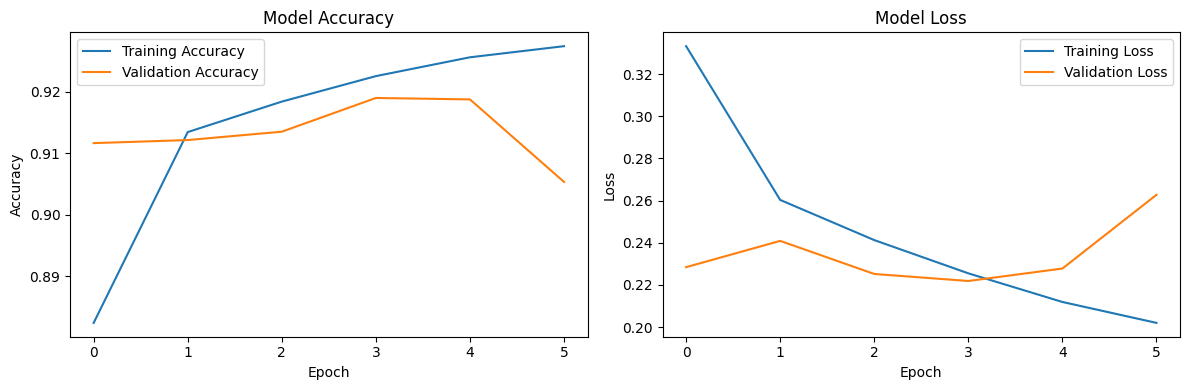

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 1. Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# 2. Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

# 1. Predictions
predictions_prob = model.predict(X_test_padded)
y_test_preds = (predictions_prob > 0.5).astype(int)

# 2. DataFrame with Retained Metadata
test_model_df = pd.DataFrame({
    'review_text': X_test_text,
    'actual_sentiment': y_test,
    'predicted_probability': predictions_prob.flatten(),
    'predicted_sentiment': y_test_preds.flatten(),
    'is_correct': (y_test == y_test_preds.flatten()),
    'app_name': app_test,  # Retained metadata from Cell [3]
    'app_category': cat_test,  # Retained metadata from Cell [3]
    'split_type': 'Test',
})

test_model_df.to_csv(
    'C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/test_model_df(after_lem_stop).csv',
    index=False,
)

941/941 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step


In [18]:
df2=pd.read_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/train_model_df(after_lem_stop.csv")

In [19]:
import pandas as pd

print('Predicting on 70k Train Data...')
train_probs = model.predict(X_train_padded)
train_preds = (train_probs > 0.5).astype(int)

trainingdata_model = pd.DataFrame({
    'review_text': X_train_text,
    'actual_sentiment': y_train,
    'predicted_probability': train_probs.flatten(),
    'predicted_sentiment': train_preds.flatten(),
    'is_correct': (y_train == train_preds.flatten()),
    'app_name': app_train,  # Retained metadata from Cell [3]
    'app_category': cat_train,  # Retained metadata from Cell [3]
    'split_type': 'Train',
})

trainingdata_model.to_csv(
    'C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/trainingdata_model_df(after_lem_stop).csv',
    index=False,
)

Predicting on 70k Train Data...
2195/2195 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step


In [20]:
df_full = pd.concat([trainingdata_model, test_model_df], axis=0, ignore_index=True)

df_full['is_correct'] = (df_full['actual_sentiment'] == df_full['predicted_sentiment'])

df_full.to_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/final_ml_1lakh(after_lem_stop).csv", index=False)

In [21]:
df4=pd.read_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/final_ml_1lakh(after_lem_stop).csv")

In [22]:
# 1. Median probability for Class 0 (Negative predictions)
median_prob_0 = df4[df4['predicted_sentiment'] == 0][
    'predicted_probability'
].median()

# 2. Median probability for Class 1 (Positive predictions)
median_prob_1 = df4[df4['predicted_sentiment'] == 1][
    'predicted_probability'
].median()

print(f"Median probability for predicting Class 0: {median_prob_0:.4f}")
print(f"Median probability for predicting Class 1: {median_prob_1:.4f}")

Median probability for predicting Class 0: 0.0178
Median probability for predicting Class 1: 0.9964


In [15]:
df4["predicted_sentiment"].value_counts()

predicted_sentiment
0    75115
1    25187
Name: count, dtype: int64

In [16]:
df4['is_correct'].value_counts()

is_correct
True     93774
False     6528
Name: count, dtype: int64